<a href="https://colab.research.google.com/github/AbhinavDharam/Netflix-Content-Strategy-Viewer-Preference-Analysis/blob/main/genre_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
from google.colab import files
uploaded = files.upload()


Saving cleaned_netflix_data.csv to cleaned_netflix_data.csv


In [27]:
df = pd.read_csv('cleaned_netflix_data.csv')

In [28]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


In [29]:
df['genre_list'] = df['listed_in'].apply(lambda x: [i.strip() for i in x.split(',')])

In [30]:
genre_df = df.explode('genre_list')
genre_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre_list
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Dramas
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Sci-Fi & Fantasy
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,International Movies


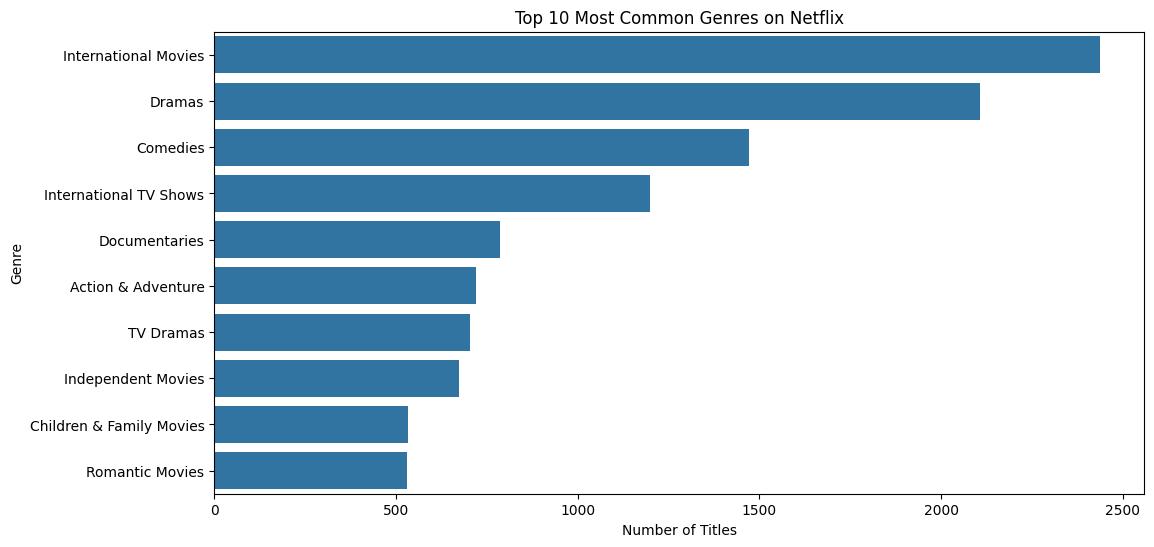

In [31]:
#Top 10 most common genres
top_genres = genre_df['genre_list'].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

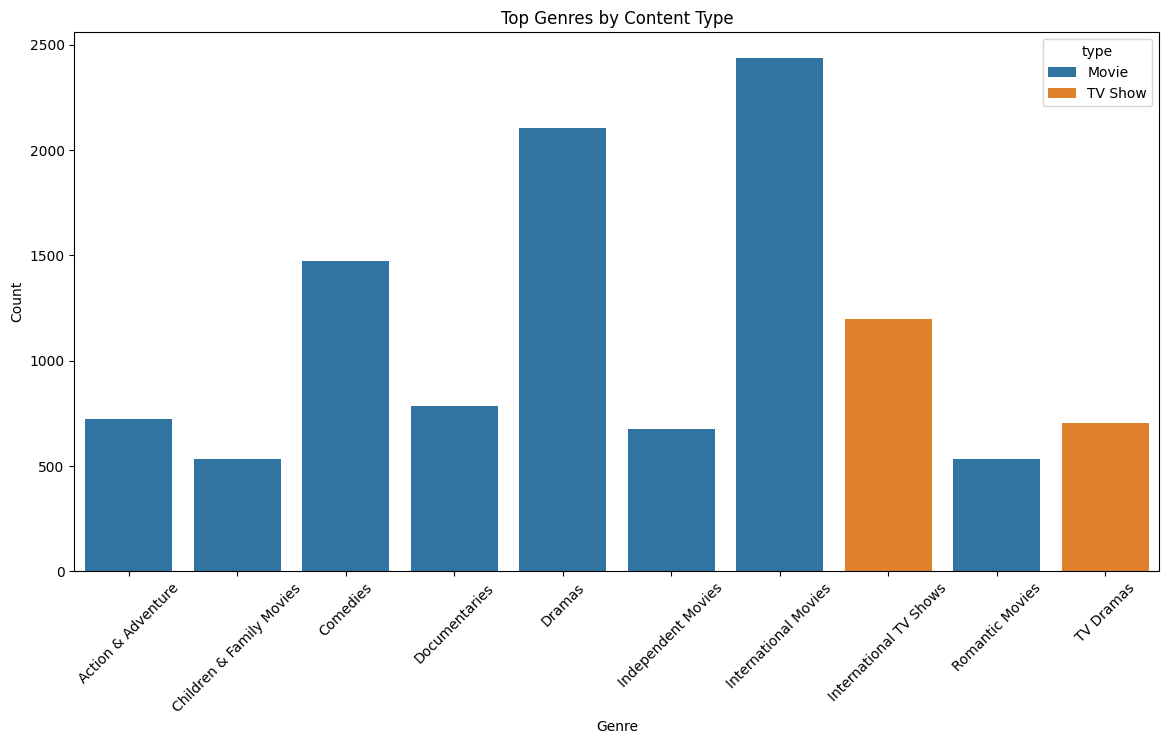

In [32]:
#Genre distribution by content type
genre_type = genre_df.groupby(['genre_list', 'type']).size().reset_index(name='count')

top10_genres = genre_df['genre_list'].value_counts().head(10).index
genre_type_top = genre_type[genre_type['genre_list'].isin(top10_genres)]

plt.figure(figsize=(14,7))
sns.barplot(data=genre_type_top, x='genre_list', y='count', hue='type')
plt.xticks(rotation=45)
plt.title("Top Genres by Content Type")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

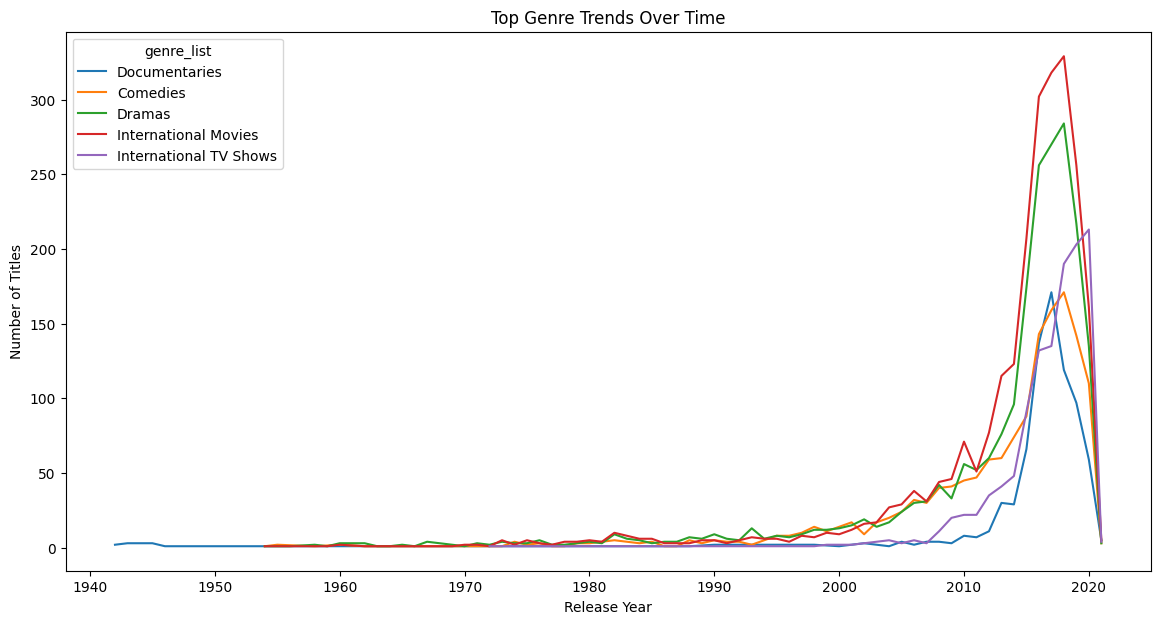

In [33]:
#Genre trend overtime
genre_year = genre_df.groupby(['release_year', 'genre_list']).size().reset_index(name='count')

top5_genres = genre_df['genre_list'].value_counts().head(5).index
genre_year_top = genre_year[genre_year['genre_list'].isin(top5_genres)]

plt.figure(figsize=(14,7))
sns.lineplot(data=genre_year_top, x='release_year', y='count', hue='genre_list')
plt.title("Top Genre Trends Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

In [34]:
#Underrepresented Genre
genre_summary = genre_df.groupby('genre_list').size().reset_index(name='total_titles')
genre_summary = genre_summary.sort_values('total_titles')

print(genre_summary.head(15))

                      genre_list  total_titles
38                      TV Shows            12
5              Classic & Cult TV            25
39                  TV Thrillers            50
31  Stand-Up Comedy & Talk Shows            52
21                        Movies            56
1                 Anime Features            57
13          Faith & Spirituality            57
9                    Cult Movies            59
40                 Teen TV Shows            60
35                     TV Horror            69
37           TV Sci-Fi & Fantasy            75
27           Science & Nature TV            85
36                  TV Mysteries            90
20                  LGBTQ Movies            90
6                 Classic Movies           103
